In [89]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

### CCTV

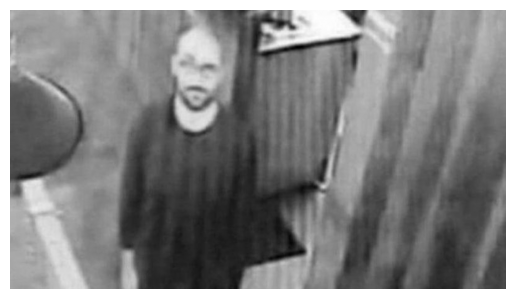

In [90]:
cctv = cv2.imread('backup.jpg')
cctv_gray = cv2.cvtColor(cctv, cv2.COLOR_BGR2GRAY)

plt.imshow(cctv_gray, cmap='gray')
plt.axis('off')
plt.show()

In [91]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * (size * size)
                    for r in range(size):
                        for c in range(size):
                            values[r * size + c] = int(region[r, c])

                    n = size * size
                    for x in range(n - 1):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]

                    canvas[i, j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

In [92]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [93]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [94]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [95]:
def fungsi_jumlah(a, b):
    return a + b
def jumlah_tiga(a, b, c):
    return a + b + c

In [96]:
img = cv2.imread("backup.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hasil_mean    = filter(img_gray, 3, 'mean')
hasil_median  = filter(img_gray, 3, 'median')
hasil_modus   = filter(img_gray, 3, 'modus')

hasil_smooth = convolution(img_gray.astype(np.float32), kernelSmoothing)
hasil_sharp  = convolution(img_gray.astype(np.float32), kernelSharpening)

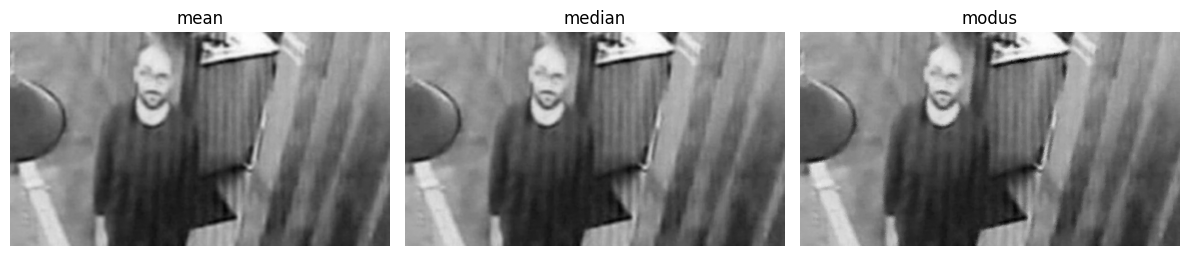

In [97]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(hasil_mean, cmap='gray')
plt.title('mean')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_median, cmap='gray')
plt.title('median')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_modus, cmap='gray')
plt.title('modus')
plt.axis('off')

plt.tight_layout()
plt.show()

untuk perbedaan mean median dan modus itu adalah cara mengambil nilainya, mean mengambil rata rata, median mengambil nilai tengah dengan catatan sudah berurutan, lalu modut mengambil nilai yang paling banyak keluar.

3 gambar di atas tidak memiliki perbedaan di mata saya. mohon maaf

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

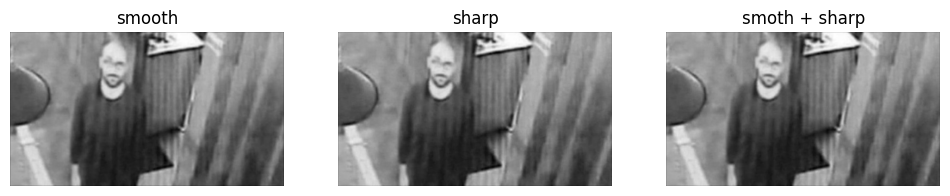

In [98]:
smooth_sharp_cctv = fungsi_jumlah (hasil_smooth, hasil_sharp)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(hasil_smooth, cmap='gray')
plt.title('smooth')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_sharp, cmap='gray')
plt.title('sharp')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(smooth_sharp_cctv, cmap='gray')
plt.title('smoth + sharp')
plt.axis('off')

gambar smooth dibandingkan dengan image awalnya terlihat lebih halus bisa dilihat dati kacamata orang di gambar yang menjadi sedikit lebih terlihat di gambar smooth

untuk perbandingan dari ketiga gambar di atas di mata saya tidak terlihat perbedaan. entah mata saya yang aneh ato apapun itu tetapi saya yakin ini itu tidak terlihat ada yang berbeda.

In [99]:
sobel_x = convolution(cctv_gray, sobelX)
sobel_y = convolution(cctv_gray, sobelY)

sobel_result = np.sqrt(
    np.square(sobel_x.astype(np.float32)) +
    np.square(sobel_y.astype(np.float32))
)

# normalisasi ke 0–255
sobel_cctv = np.clip(sobel_result, 0, 255)
sobel_cctv = sobel_cctv.astype(np.uint8)

In [100]:
prewitt_x = convolution(cctv_gray, prewittX)
prewitt_y = convolution(cctv_gray, prewittY)

prewit_cctv = np.sqrt(
    np.square(prewitt_x.astype(np.float32)) +
    np.square(prewitt_y.astype(np.float32))
)

prewit_cctv = np.clip(prewit_cctv, 0, 255)
prewit_cctv = prewit_cctv.astype(np.uint8)

In [101]:
roberts_x = convolution(cctv_gray, robertsX)
roberts_y = convolution(cctv_gray, robertsY)

roberts_cctv = np.sqrt(
    np.square(roberts_x.astype(np.float32)) +
    np.square(roberts_y.astype(np.float32))
)

roberts_cctv = np.clip(roberts_cctv, 0, 255)
roberts_cctv = roberts_cctv.astype(np.uint8)

In [102]:
prewit_sobel_cctv = fungsi_jumlah(prewit_cctv, sobel_cctv)
prewit_roberts_cctv = fungsi_jumlah(prewit_cctv, roberts_cctv)
sobel_roberts_cctv = fungsi_jumlah(sobel_cctv, roberts_cctv)
prewit_sobel_roberts_cctv = jumlah_tiga(prewit_cctv, sobel_cctv, roberts_cctv)


(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

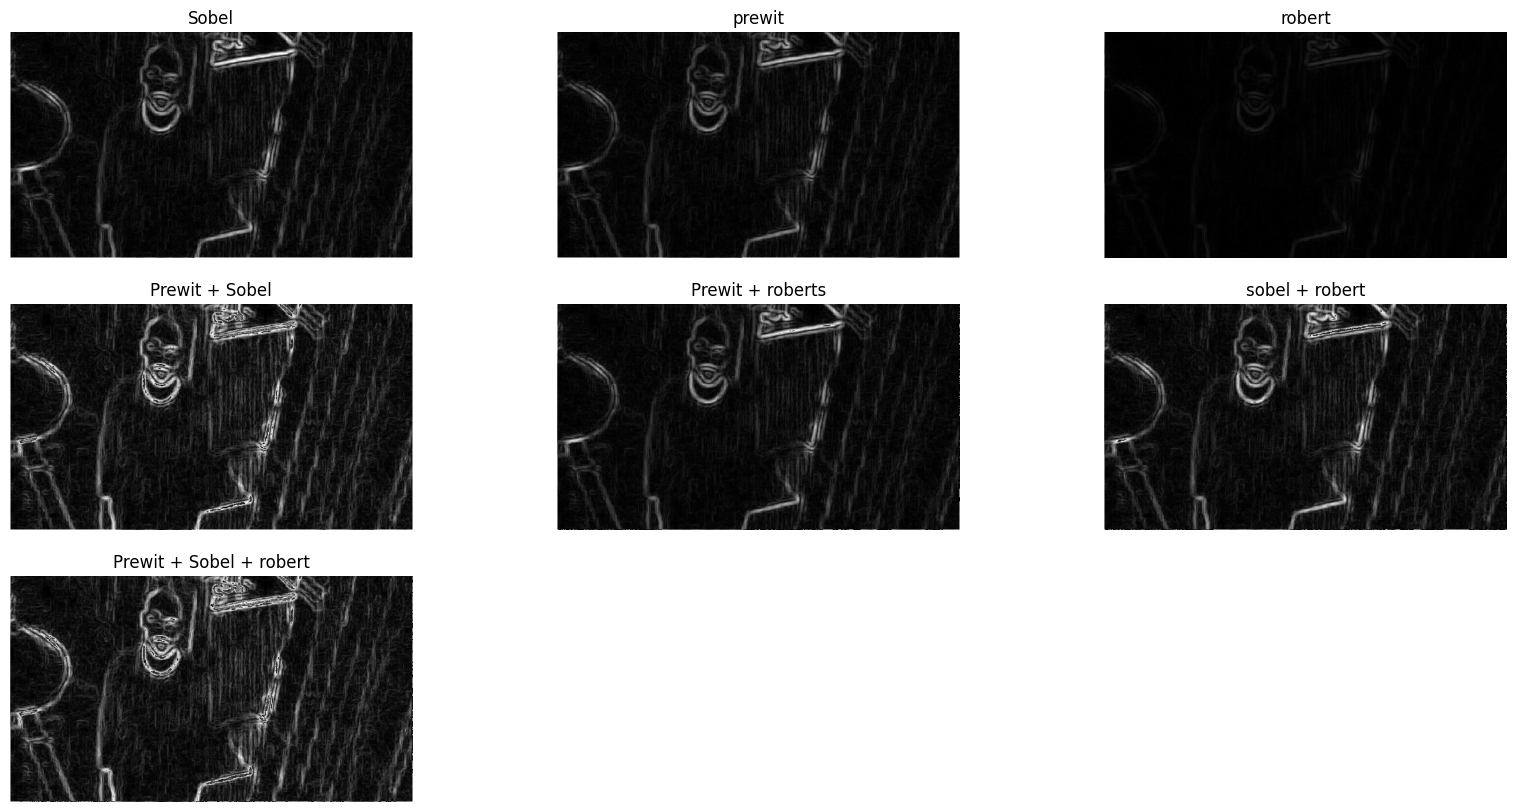

In [103]:
plt.figure(figsize=(20,10))

plt.subplot(3,3,1)
plt.imshow(sobel_cctv, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(prewit_cctv, cmap='gray')
plt.title('prewit')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(roberts_cctv, cmap='gray')
plt.title('robert')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(prewit_sobel_cctv, cmap='gray')
plt.title('Prewit + Sobel')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(prewit_roberts_cctv, cmap='gray')
plt.title('Prewit + roberts')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(sobel_roberts_cctv, cmap='gray')
plt.title('sobel + robert')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(prewit_sobel_roberts_cctv, cmap='gray')
plt.title('Prewit + Sobel + robert')
plt.axis('off')

pada gambar di atas mendeteksi tepi dengan menggunakan operator sobel memiliki keakuratan yang lebih abik dari pada dua operator lainnya, untuk prewit hampis seperti sobel tetapi kurang akurat dikit, lalu untuk robert yang paling tidak akurat untu deteksi tepi.

kombinasi operator prewit dan sobet bisa dibilang kombinasi antara 2 operatoor yang paling bagus, lalu semakin banyak operator yang di gunakan semakin akurat hasil deteksi tepinya.

In [104]:
def treshold_tepi(img, treshold):
    return (img > treshold).astype(np.uint8) * 255

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

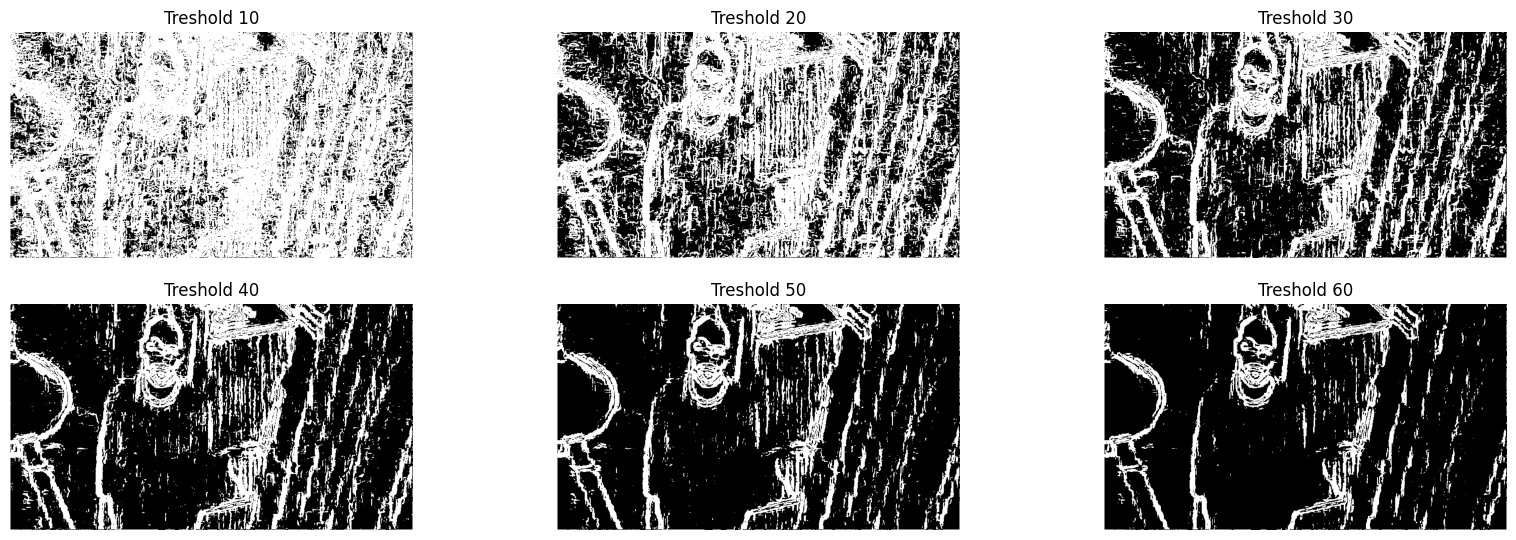

In [105]:
sobel_cctv_treshold10 = treshold_tepi(prewit_sobel_roberts_cctv, 10)
sobel_cctv_treshold20 = treshold_tepi(prewit_sobel_roberts_cctv, 20)
sobel_cctv_treshold30 = treshold_tepi(prewit_sobel_roberts_cctv, 30)
sobel_cctv_treshold40 = treshold_tepi(prewit_sobel_roberts_cctv, 40)
sobel_cctv_treshold50 = treshold_tepi(prewit_sobel_roberts_cctv, 50)
sobel_cctv_treshold60 = treshold_tepi(prewit_sobel_roberts_cctv, 60)
plt.figure(figsize=(20,10))

plt.subplot(3,3,1)
plt.imshow(sobel_cctv_treshold10, cmap='gray')
plt.title('Treshold 10')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(sobel_cctv_treshold20, cmap='gray')
plt.title('Treshold 20')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(sobel_cctv_treshold30, cmap='gray')
plt.title('Treshold 30')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(sobel_cctv_treshold40, cmap='gray')
plt.title('Treshold 40')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(sobel_cctv_treshold50, cmap='gray')
plt.title('Treshold 50')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(sobel_cctv_treshold60, cmap='gray')
plt.title('Treshold 60')
plt.axis('off')


## PAS FOTO

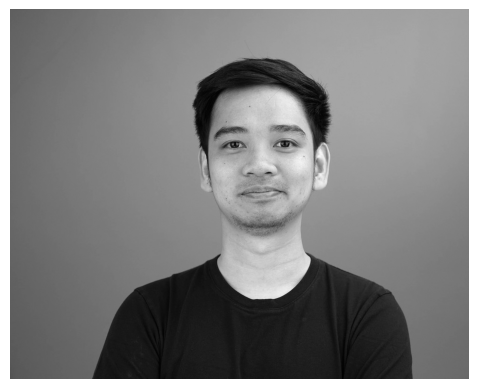

In [106]:
david = cv2.imread('david.jpg')
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)

plt.imshow(david_gray, cmap='gray')
plt.axis('off')
plt.show()

In [107]:
sobel_x = convolution(david_gray, sobelX)
sobel_y = convolution(david_gray, sobelY)

sobel_result = np.sqrt(
    np.square(sobel_x.astype(np.float32)) +
    np.square(sobel_y.astype(np.float32))
)

# normalisasi ke 0–255
sobel_david = np.clip(sobel_result, 0, 255)
sobel_david = sobel_david.astype(np.uint8)

In [108]:
prewitt_x = convolution(david_gray, prewittX)
prewitt_y = convolution(david_gray, prewittY)

prewit_david = np.sqrt(
    np.square(prewitt_x.astype(np.float32)) +
    np.square(prewitt_y.astype(np.float32))
)

prewit_david = np.clip(prewit_david, 0, 255)
prewit_david = prewit_david.astype(np.uint8)

In [109]:
roberts_x = convolution(david_gray, robertsX)
roberts_y = convolution(david_gray, robertsY)

robert_david = np.sqrt(
    np.square(roberts_x.astype(np.float32)) +
    np.square(roberts_y.astype(np.float32))
)

robert_david = np.clip(robert_david, 0, 255)
robert_david = robert_david.astype(np.uint8)

In [110]:
def treshold_rgb(img, treshold):
    return (img > treshold).astype(np.uint8) * 255

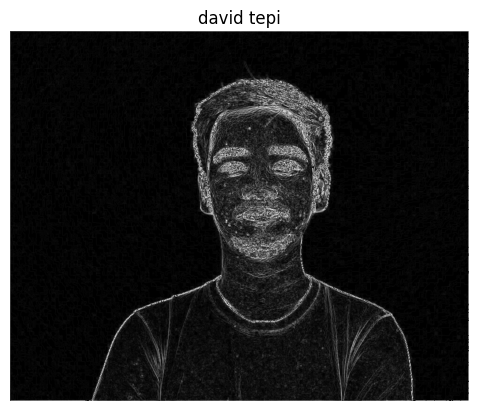

In [111]:
prewit_sobel_roberts_david = jumlah_tiga(prewit_david, sobel_david, robert_david)

plt.imshow(prewit_sobel_roberts_david, cmap='gray')
plt.title('david tepi')
plt.axis('off')
plt.show()